# **Lab: Data Pipeline 2**

## Exercise 1: Airflow basics

In this exercise, we will learn how to build a simple DAG before running it on Airflow. This exercise will help you get familliar with a DAG structure and Airflow's GUI.

Requirements:
- Install Dbeaver (https://dbeaver.io/download/)
- Install Postgres driver (https://dbeaver.com/docs/wiki/Database-drivers/)


The steps are:
1.   Setup Airflow
2.   Setup DAG settings
3.   Setup DAG custom logics
4.   Setup DAG operators
5.   Airflow DAG triggering
6.   Ariflow DAG backfilling


# 1. Set up Airflow

**[1.1]** Make a copy of "dag_template.py" and call it "dag_exercise_1.py".

**[1.2]** Open the Airflow UI

# 2. Setup DAG settings

**[2.1]** Open "dag_exercise_1.py" then:

*   Import the "logging" library
*   Replace the values for these variables:
1.   **'owner'**:'BDE_LAB_6'
2.   **'start_date'**:'datetime.now() - timedelta(days=1)'
3.   **'dag_id'**: 'exercise_1'
4.   **'schedule_interval'**:'@hourly'




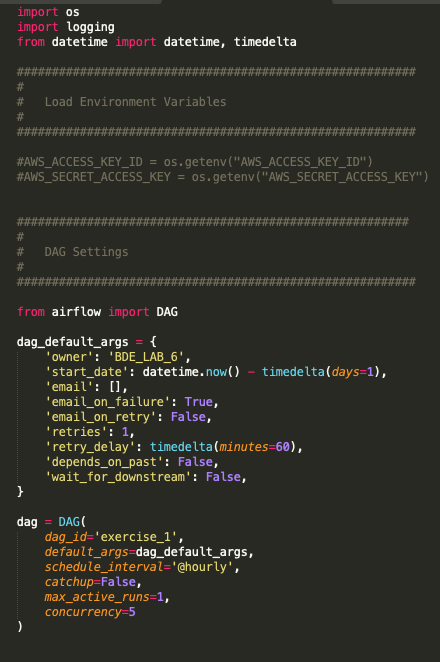

# 3. Setup DAG custom logics

**[3.1]** Delete the two functions "do_something_1_func" and "do_something_2_func".

Then add a new function "print_bde" which will use the *logging* library to add the following message "Big Data Engineering" in Airflow's logs:




In [ ]:
def print_bde():
    logging.info("Big Data Engineering")

**[3.2]** Add a new function "addition" which will display the following operation "42 + 88 = " and its result in Airflow's logs:




In [ ]:
def addition():
    logging.info(f"42 + 88 = {42+88}")

**[3.3]** Add a new function "substraction" which will display the following operation "6 - 2 = " and its result in Airflow's logs:




In [ ]:
def subtraction():
    logging.info(f"6 -2 = {6-2}")

**[3.4]** Add a new function "division" which will display the following operation "10 / 2 = " and its result in Airflow's logs:




In [ ]:
def division():
    logging.info(f"10 / 2 = {int(10/2)}")

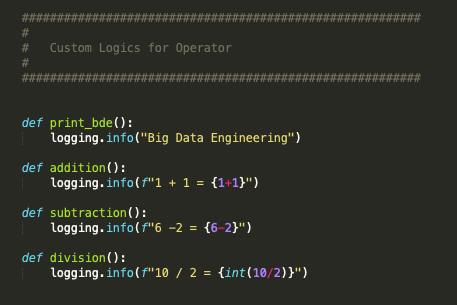

# 4. Setup DAG operators

**[4.1]** Delete the two tasks "do_something_1_task" and "do_something_2_task".

Then add a new PythonOperator task called "print_bde_task" with:


*   task_id="print_bde_task_id"
*   python_callable=print_bde
*   dag=dag







In [ ]:
print_bde_task = PythonOperator(
    task_id="print_bde_task_id",
    python_callable=print_bde,
    dag=dag)

**[4.2]** Add a new PythonOperator task called "addition_task" with:
*   task_id="addition_task_id"
*   python_callable=addition
*   dag=dag



In [ ]:
addition_task = PythonOperator(
    task_id="addition_task_id",
    python_callable=addition,
    dag=dag)

**[4.3]** Add a new PythonOperator task called "subtraction_task" with:
*   task_id="subtraction_task_id"
*   python_callable=subtraction
*   dag=dag



In [ ]:
subtraction_task = PythonOperator(
    task_id="subtraction_task_id",
    python_callable=subtraction,
    dag=dag)

**[4.4]** Add a new PythonOperator task called "division_task" with:
*   task_id="division_task_id"
*   python_callable=division
*   dag=dag



In [ ]:
division_task = PythonOperator(
    task_id="division_task_id",
    python_callable=division,
    dag=dag)

**[4.5]** Delete "do_something_1_task >> do_something_2_task"

Then configure the task dependencies such that the graph looks like the following:

After finishing, save the file.





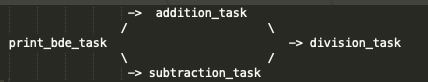

In [ ]:
print_bde_task >> [addition_task,subtraction_task]
[addition_task,subtraction_task] >> division_task

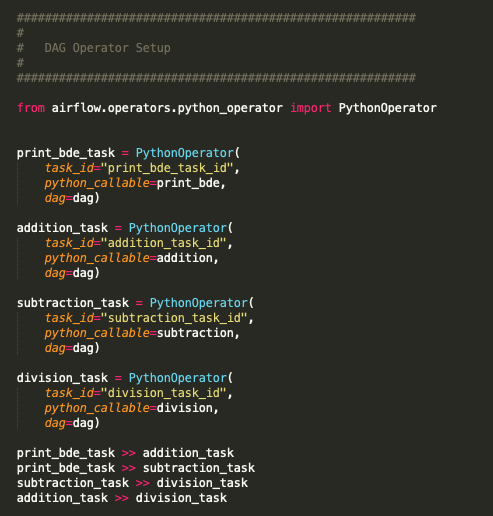

# 5. Airflow DAG triggering

**[5.1]** In Airflow, click on the DAG called "exercise_1" then go to the Graph view:








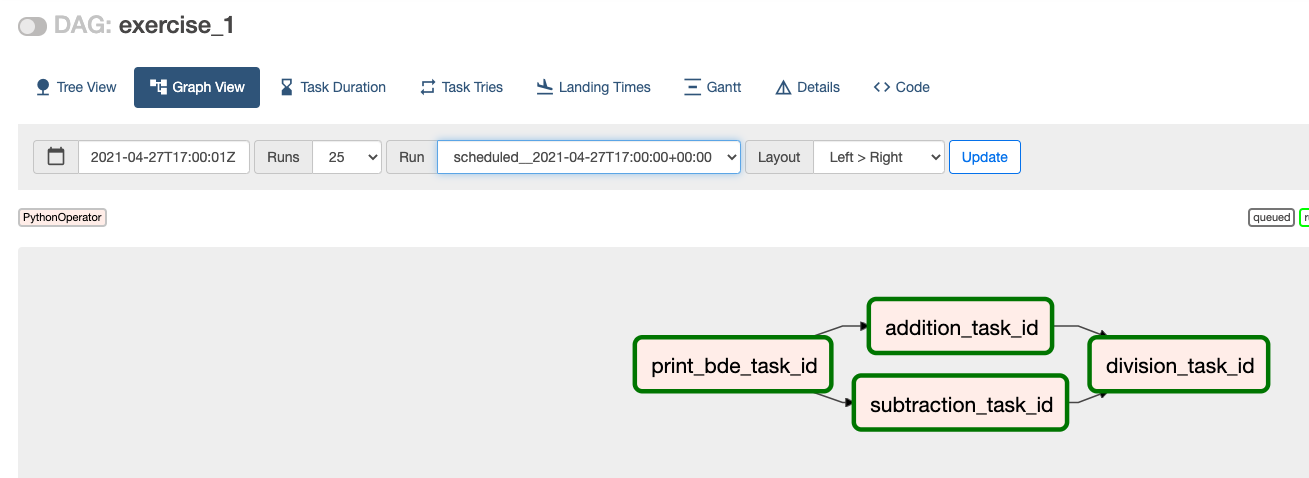

**[5.2]** Go to the Tree view and press on the toggle button to unpause the DAG:








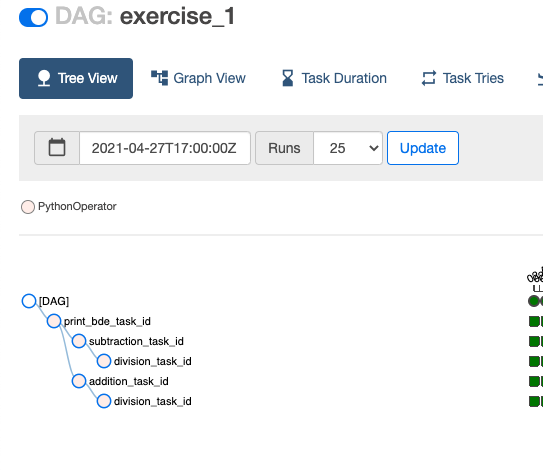

**[5.3]** After the job has been completed (all tasks are greens), click on each task and check the logs to find the printed messages.







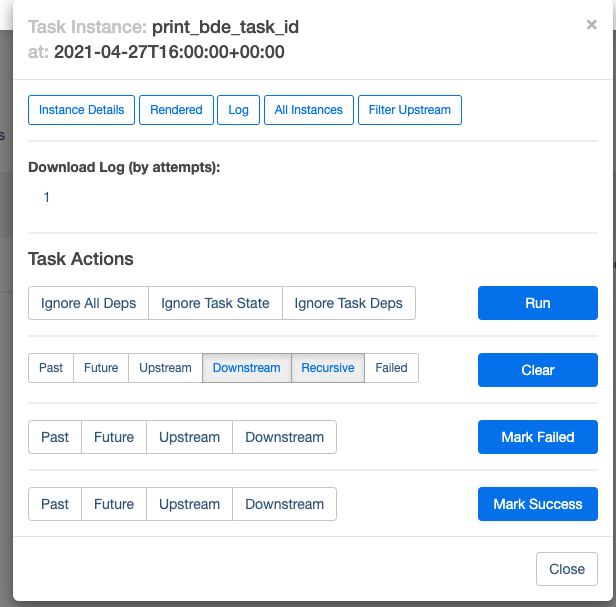

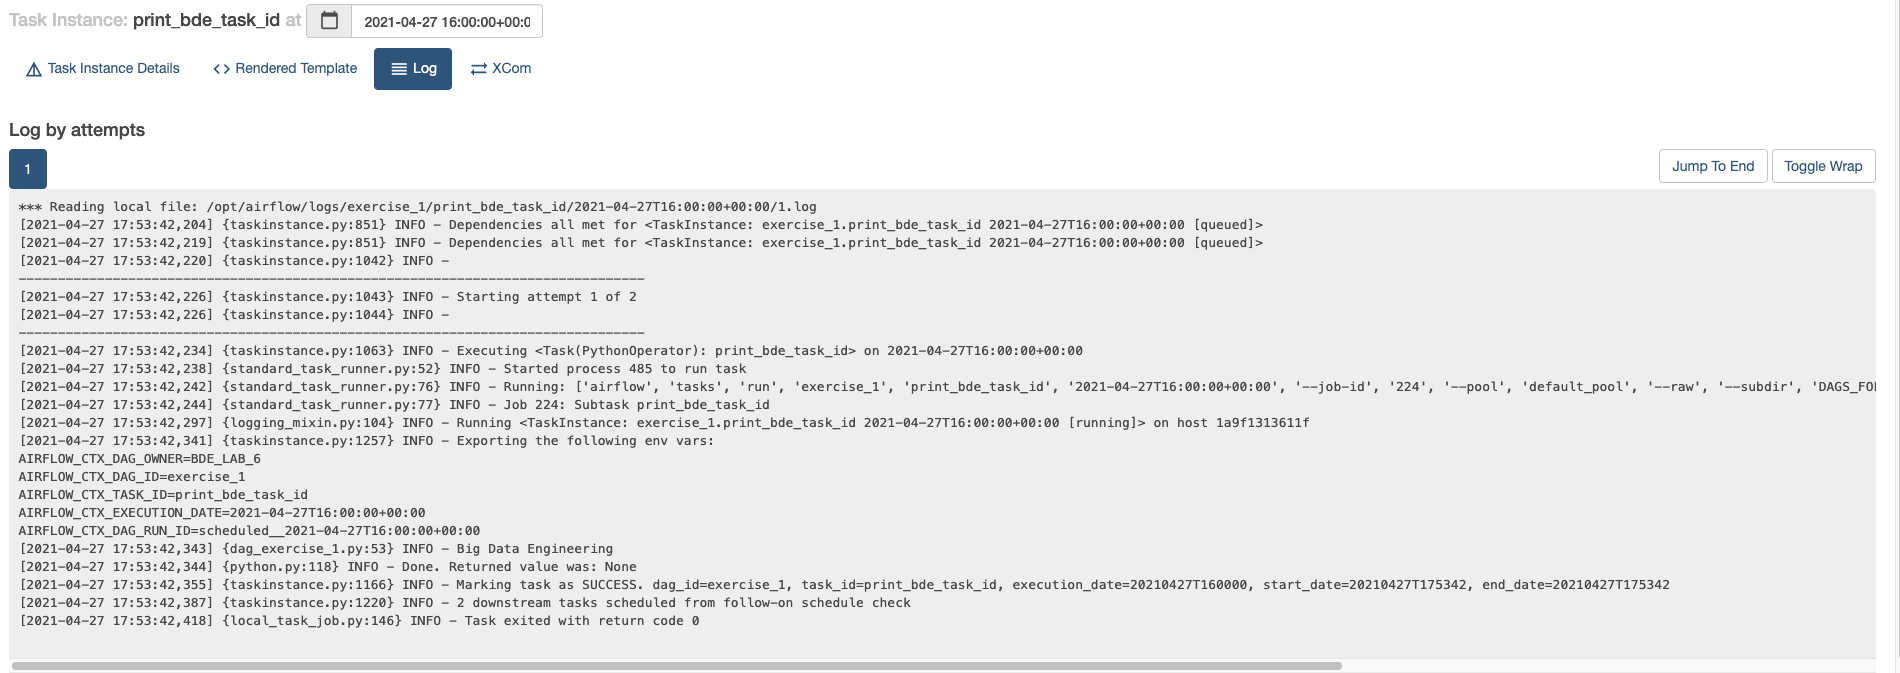

# 6. Airflow DAG backfilling

**[6.1]** Pause the DAG









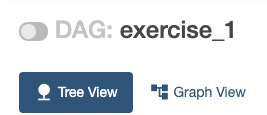

**[6.2]** Open "dag_exercise_1.py" and in the DAG Settings change:

1.   **"catchup"** to True

Saved the file and return to Airflow.









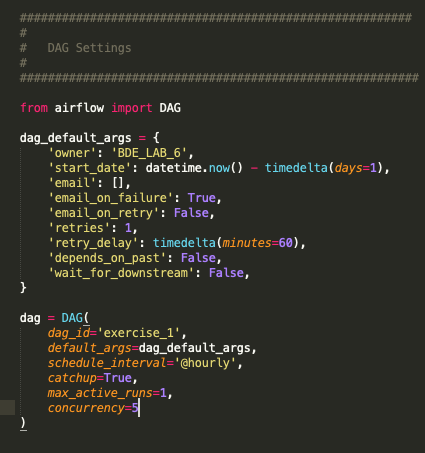

**[6.3]** In Airflow, click on the DAG "exercise_1" then go to "Code". Press on the "refresh" button and check that the code has been updated:









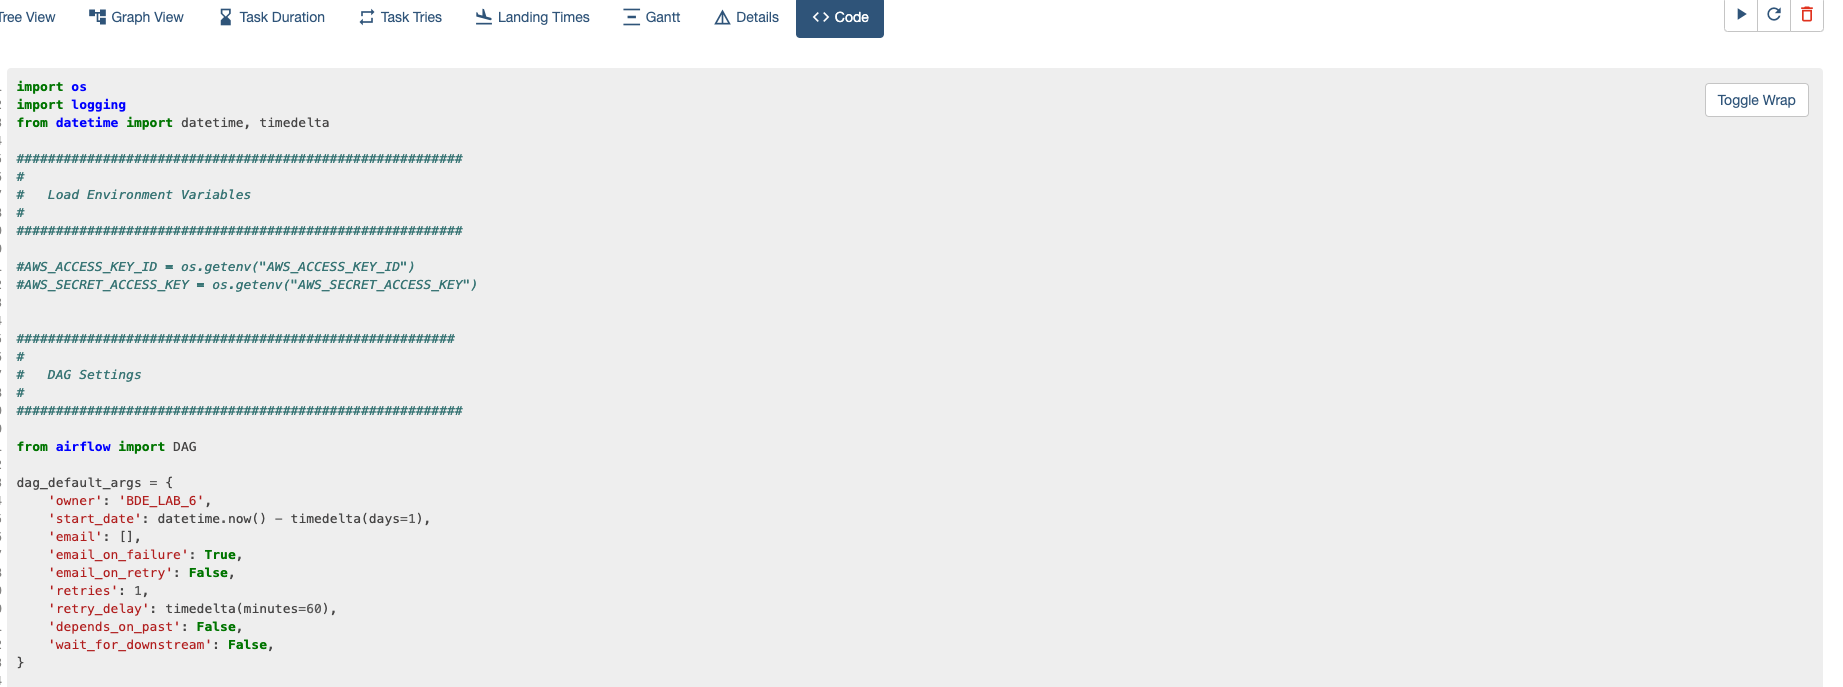

**[6.4]** Go back to the home page and click on the successfull runs. Then select all runs and delete them:







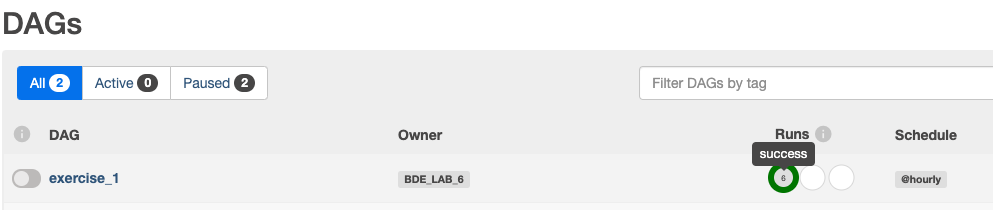

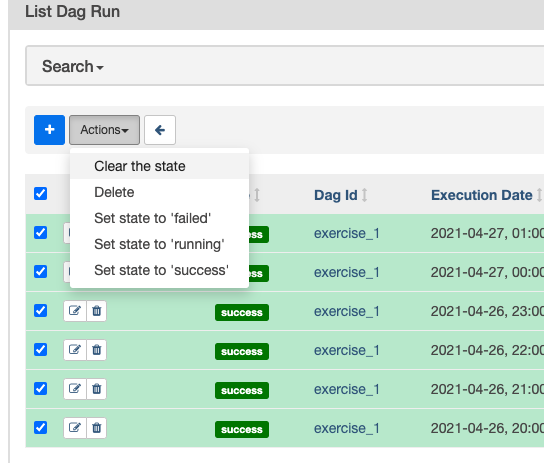

**[6.5]** Go to the Tree View and unpause the DAG.

After a couple of minutes, you should see Airflow trying to backfilled the previous scheduled runs.








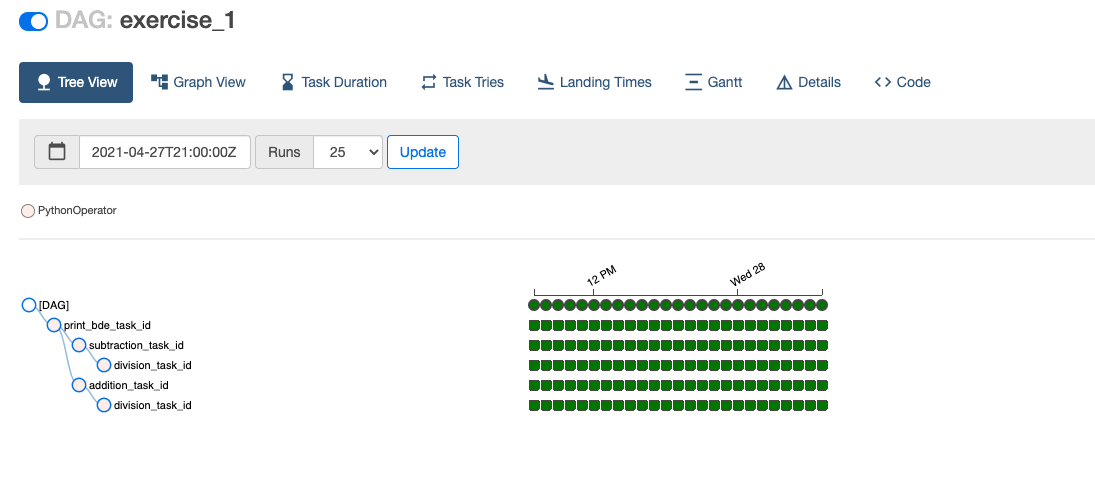